In [4]:
library(tidyverse)
library(ggplot2)
library(lubridate)
library(zoo)

In [5]:
crime_all <- read_csv("Original_Crime_data/crime_in_vancouver.csv")|>
    mutate(date = as.Date(paste(year, month, day, sep = "-")))|>
    filter(!is.na(time_category))|>
    select(type, date, year, month, geo_local_area, time_category)|>
    glimpse()

Rows: 811320 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): type, hundred_block, geo_local_area, time_category
dbl (4): year, month, day, hour

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 811,320
Columns: 6
$ type           <chr> "Break and Enter Commercial", "Break and Enter Commerci…
$ date           <date> 2012-12-14, 2019-03-07, 2019-08-27, 2021-04-26, 2014-0…
$ year           <dbl> 2012, 2019, 2019, 2021, 2014, 2020, 2021, 2022, 2005, 2…
$ month          <dbl> 12, 3, 8, 4, 8, 7, 11, 1, 11, 5, 7, 6, 4, 9, 1, 11, 2, …
$ geo_local_area <chr> "South Cambie", "Fairview", "West End", "West End", "We…
$ time_category  <chr> "day", "night", "night", "night", "night", "night", "ni…


In [6]:
# monthly_counts <- crime_all|>
#   group_by(time_category, YEAR, MONTH)|>
#   summarise(crime_count = n(), .groups = "drop")

# avg_monthly_counts <- monthly_counts %>%
#   group_by(time_category, MONTH) %>%
#   summarise(avg_crime = mean(crime_count), .groups = "drop")|>
#   filter(!is.na(time_category))

# ggplot(avg_monthly_counts, aes(x = MONTH, y = avg_crime, color = time_category, group = time_category)) +
#   geom_line(size = 1) +
#   geom_point(size = 2) +
#   scale_x_continuous(breaks = 1:12, labels = month.abb) +
#   labs(x = "Month", y = "Average Crime Count", 
#        title = "Average Monthly Crime Counts by Time Category",
#        color = "Time Category") +
#   theme_minimal()

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."
`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`)."


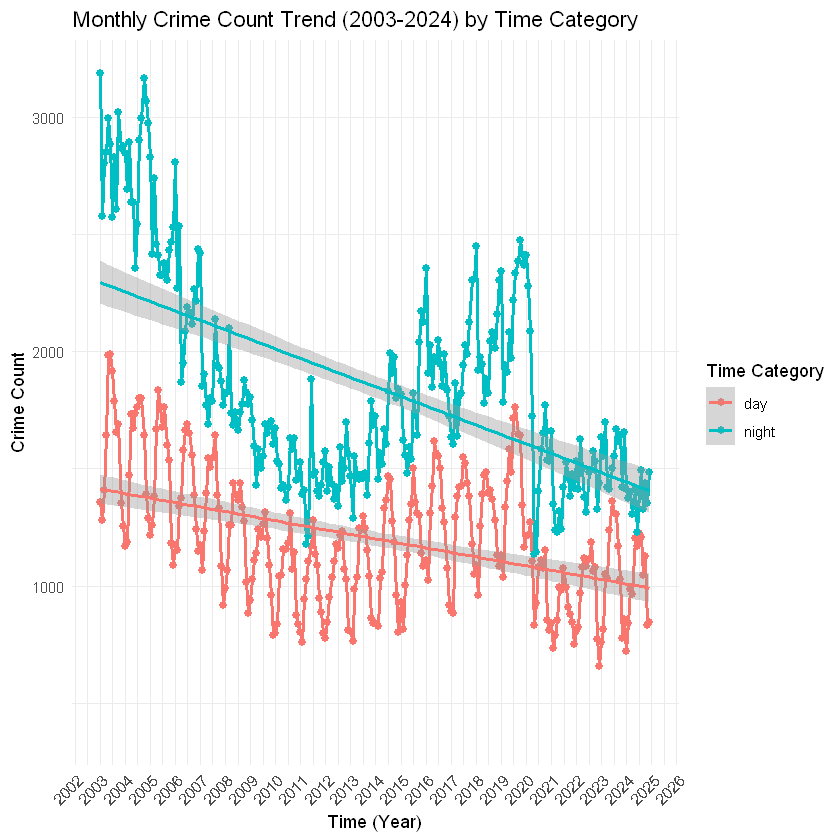

In [7]:
crime_trend <- crime_all|>
    group_by(time_category, year, month)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))

ggplot(crime_trend, aes(x = date, y = crime_count, color = time_category, group = time_category)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2003-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2003-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 318 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 318 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 318 rows containing missing values or values outside the scale range
(`geom_point()`)."


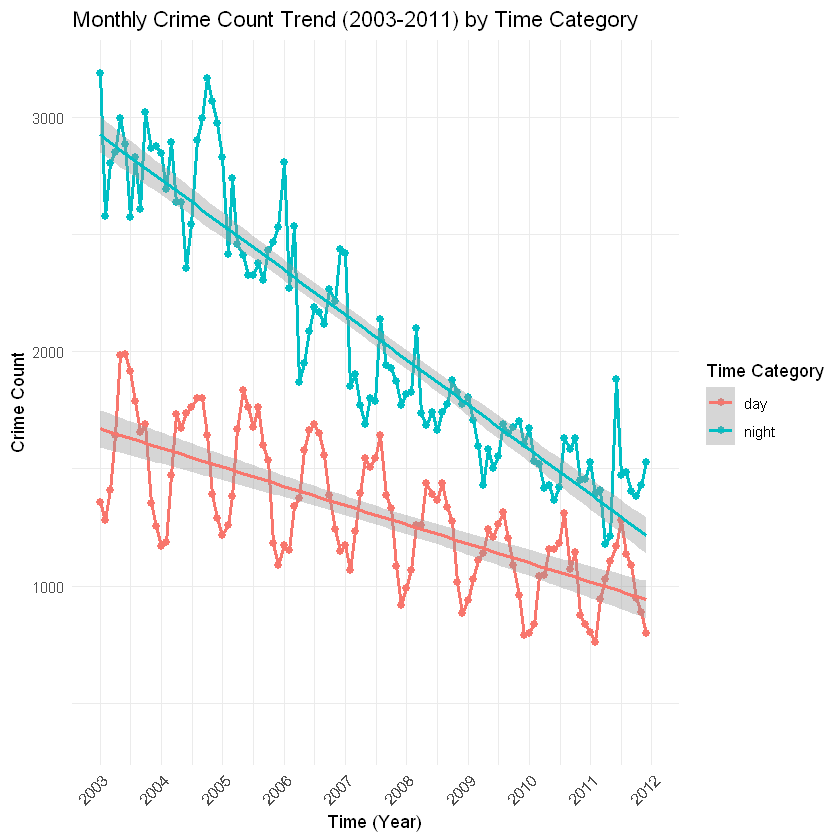

In [8]:
ggplot(crime_trend, aes(x = date, y = crime_count, color = time_category, group = time_category)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2003-01-01", "2011-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2003-2011) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 246 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 246 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 246 rows containing missing values or values outside the scale range
(`geom_point()`)."


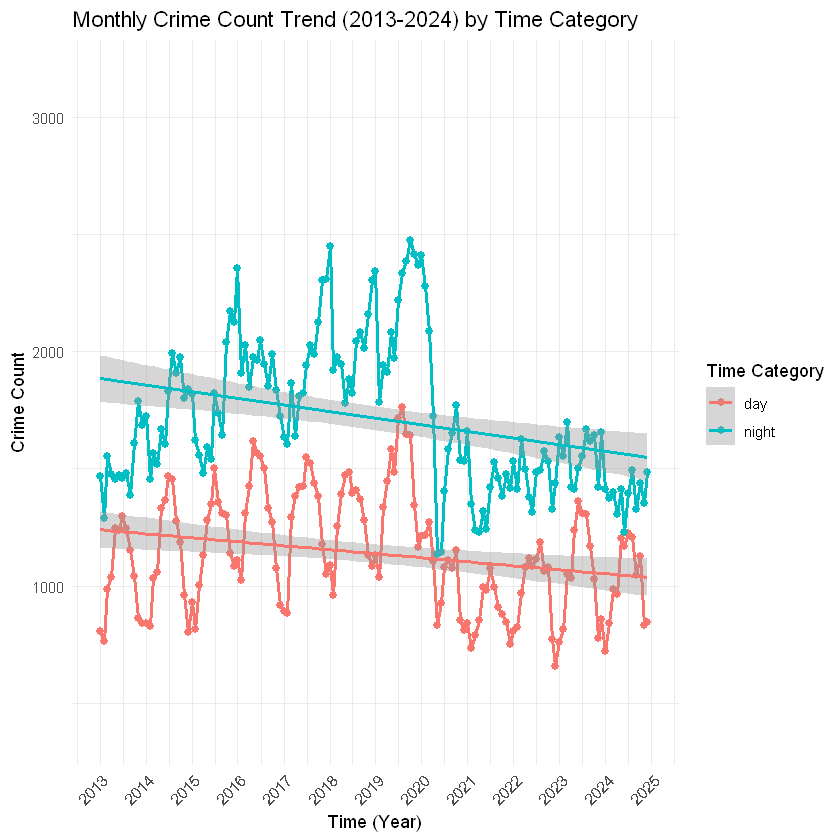

In [9]:
ggplot(crime_trend, aes(x = date, y = crime_count, color = time_category, group = time_category)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [10]:
lum_data <- read_csv("NTL_data/ntl_vancouver_monthly_total_ntl.csv")|>
    glimpse()

Rows: 78 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (4): total_ntl, total_pixels, weighted_ntl_mean, prev_weighted_ntl_mean
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 78
Columns: 5
$ date                   <date> 2012-01-01, 2012-03-01, 2012-05-01, 2012-07-01…
$ total_ntl              <dbl> NA, 9.5066512, -3.7940151, 1.8771791, 9.7744734…
$ total_pixels           <dbl> 3650, 3853, 3868, 3868, 3868, 3434, 3862, 3861,…
$ weighted_ntl_mean      <dbl> 4.522459, 4.952393, 4.764499, 4.853937, 5.32838…
$ prev_weighted_ntl_mean <dbl> NA, 4.522459, 4.952393, 4.764499, 4.853937, 5.3…


`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`)."


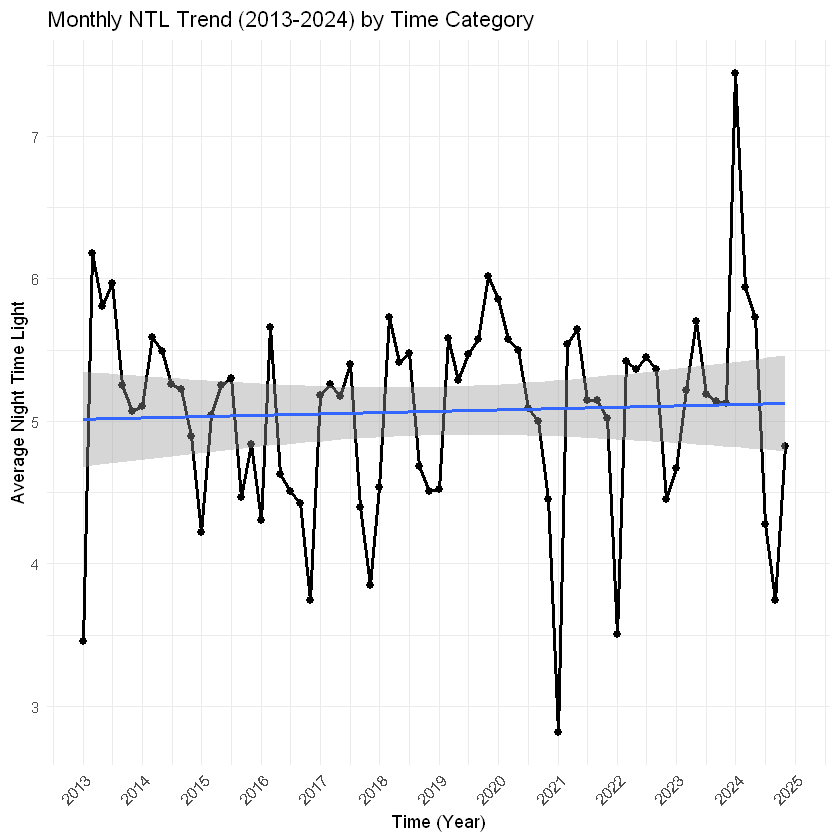

In [11]:
ggplot(lum_data, aes(x = date, y = weighted_ntl_mean)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

,date,time_category,year,month,crime_count,total_ntl,total_pixels,weighted_ntl_mean,prev_weighted_ntl_mean
,<date>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,2012-01-01,day,2012,1,774,NA,3650,4.522459,NA
2,2012-01-01,night,2012,1,1574,NA,3650,4.522459,NA
3,2012-03-01,night,2012,3,1507,9.506651,3853,4.952393,4.522459
4,2012-03-01,day,2012,3,953,9.506651,3853,4.952393,4.522459
5,2012-05-01,day,2012,5,1103,-3.794015,3868,4.764499,4.952393
6,2012-05-01,night,2012,5,1368,-3.794015,3868,4.764499,4.952393



Call:
lm(formula = crime_count ~ weighted_ntl_mean, data = merged_data)

Residuals:
   Min     1Q Median     3Q    Max 
-739.1 -300.9  -37.7  224.1 1030.9 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)        1357.53     237.88   5.707 5.74e-08 ***
weighted_ntl_mean    13.78      46.71   0.295    0.768    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 406.5 on 154 degrees of freedom
Multiple R-squared:  0.0005648,	Adjusted R-squared:  -0.005925 
F-statistic: 0.08704 on 1 and 154 DF,  p-value: 0.7684


`geom_smooth()` using formula = 'y ~ x'


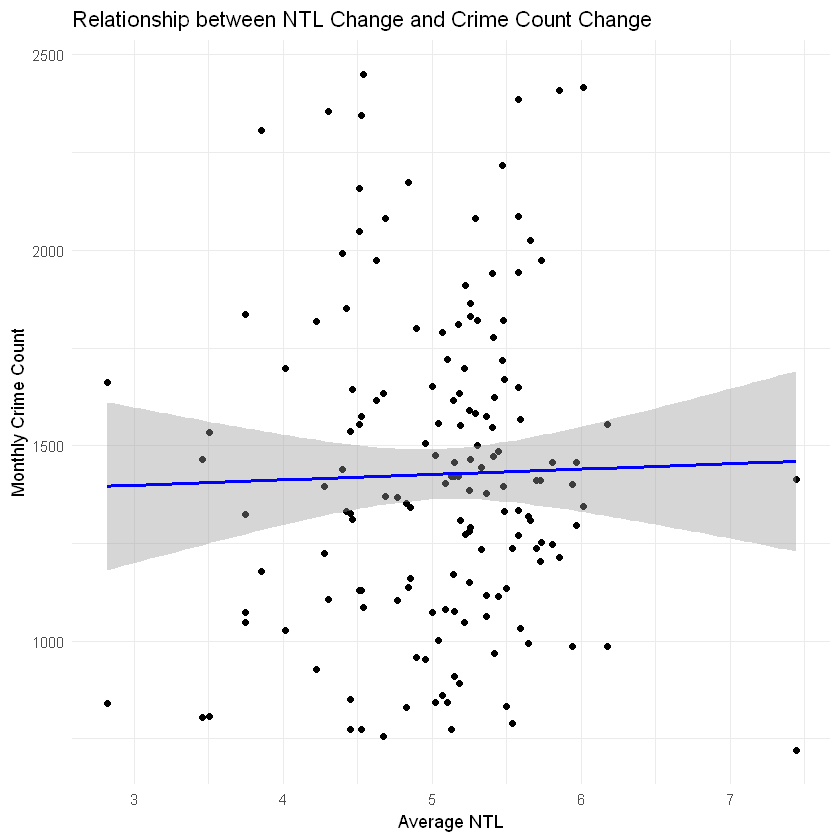

In [12]:
# Since both datasets have a date variable (format similar to "1月 2012"), we can use it to merge the data
merged_data <- merge(crime_trend, lum_data, by = "date")

# Check merge results
head(merged_data)

# Note:
# In the merged data, variables with the same name from both files will automatically get .x and .y suffixes
# Here, crime data percent change is pct_change.x, ntl is pct_change.y


# Run linear regression, using NTL percent change to predict crime rate percent change
reg_model <- lm(crime_count ~ weighted_ntl_mean, data = merged_data)
summary(reg_model)

# Create scatter plot with regression line
ggplot(merged_data, aes(x = weighted_ntl_mean, y = crime_count)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(x = "Average NTL", y = "Monthly Crime Count",
       title = "Relationship between NTL Change and Crime Count Change") +
  theme_minimal()


In [45]:
crime_summary_neighbourhood <- crime_all|>
    filter(year != 2025)|>
    filter(!geo_local_area %in% c(NA, "Musqueam", "Stanley Park"))|>
    group_by(geo_local_area)|>
    summarise(crime_count = n())|>
    arrange(desc(crime_count))

print(crime_summary_neighbourhood)

# A tibble: 22 × 2
   geo_local_area           crime_count
   <chr>                          <int>
 1 Downtown                      221662
 2 West End                       73711
 3 Fairview                       51612
 4 Mount Pleasant                 50280
 5 Strathcona                     46084
 6 Grandview-Woodland             46030
 7 Renfrew-Collingwood            42222
 8 Kitsilano                      41390
 9 Kensington-Cedar Cottage       33436
10 Hastings-Sunrise               28159
# ℹ 12 more rows


In [32]:
daily_ntl <- read_csv("NTL_data/ntl_2012_2024_daily.csv")|>
    filter(!is.na(ntl_mean))|>
    glimpse()

Rows: 4749 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,830
Columns: 5
$ ntl_mean           <dbl> 4.346262, 4.281751, 4.284582, 4.283045, 4.015064, 4…
$ n_pixels           <dbl> 907, 907, 907, 907, 907, 907, 907, 907, 907, 907, 9…
$ n_non_na_pixels    <dbl> 887, 890, 891, 889, 905, 905, 907, 903, 903, 904, 9…
$ prop_non_na_pixels <dbl> 0.9779493, 0.9812569, 0.9823594, 0.9801544, 0.99779…
$ date               <date> 2012-01-19, 2012-01-20, 2012-01-21, 2012-01-22, 20…


`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 275 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 275 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 275 rows containing missing values or values outside the scale range
(`geom_point()`)."


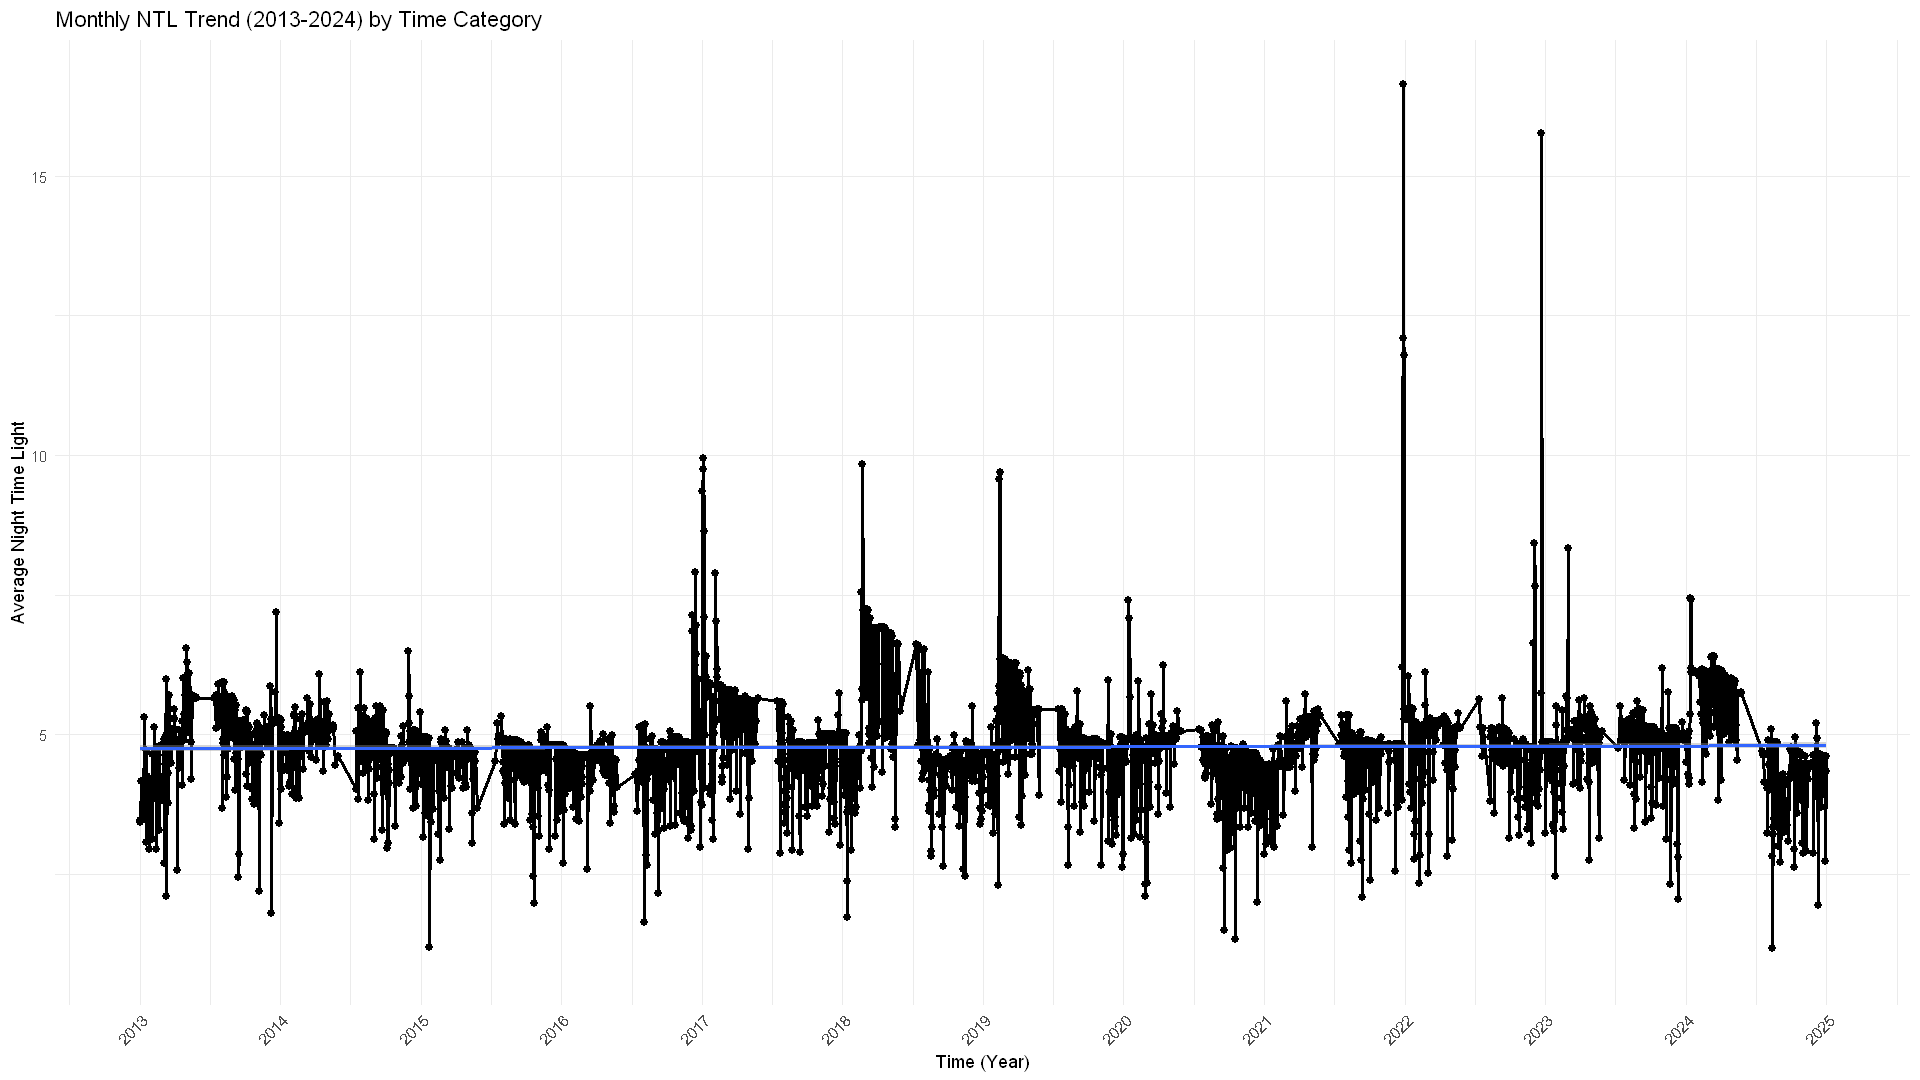

In [33]:
options(repr.plot.width = 16, repr.plot.height = 9)

ggplot(daily_ntl, aes(x = date, y = ntl_mean)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [35]:
daily_ntl <- daily_ntl|>
    arrange(desc(ntl_mean))

head(daily_ntl, 10)

ntl_mean,n_pixels,n_non_na_pixels,prop_non_na_pixels,date
<dbl>,<dbl>,<dbl>,<dbl>,<date>
16.649954,907,905,0.9977949,2021-12-27
15.769461,907,904,0.9966924,2022-12-22
12.100985,907,903,0.9955899,2021-12-28
11.797810,907,903,0.9955899,2021-12-29
9.943578,907,904,0.9966924,2017-01-04
9.845053,907,900,0.9922822,2018-02-22
9.748865,907,904,0.9966924,2017-01-03
9.692175,907,905,0.9977949,2019-02-14
9.578393,907,904,0.9966924,2019-02-11


In [40]:
ntl_12_24_monthly <- read_csv("NTL_data/22_ntl_2012_2024_monthly.csv")|>
    filter(!is.na(ntl_mean))|>
    mutate(date = as.Date(paste0(date, "-01"), format = "%Y-%m-%d"))|>
    glimpse()

Rows: 3432 Columns: 7


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): name, geo_point_2d, date
dbl (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,146
Columns: 7
$ name               <chr> "Downtown", "Hastings-Sunrise", "Kerrisdale", "Marp…
$ geo_point_2d       <chr> "{ \"lon\": -123.11656700827415, \"lat\": 49.280747…
$ ntl_mean           <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …
$ n_pixels           <dbl> 54, 71, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 69,…
$ n_non_na_pixels    <dbl> 54, 53, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 45,…
$ prop_non_na_pixels <dbl> 1.0000000, 0.7464789, 1.0000000, 1.0000000, 1.00000…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


Warning message:
"Removed 242 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 242 rows containing missing values or values outside the scale range
(`geom_point()`)."


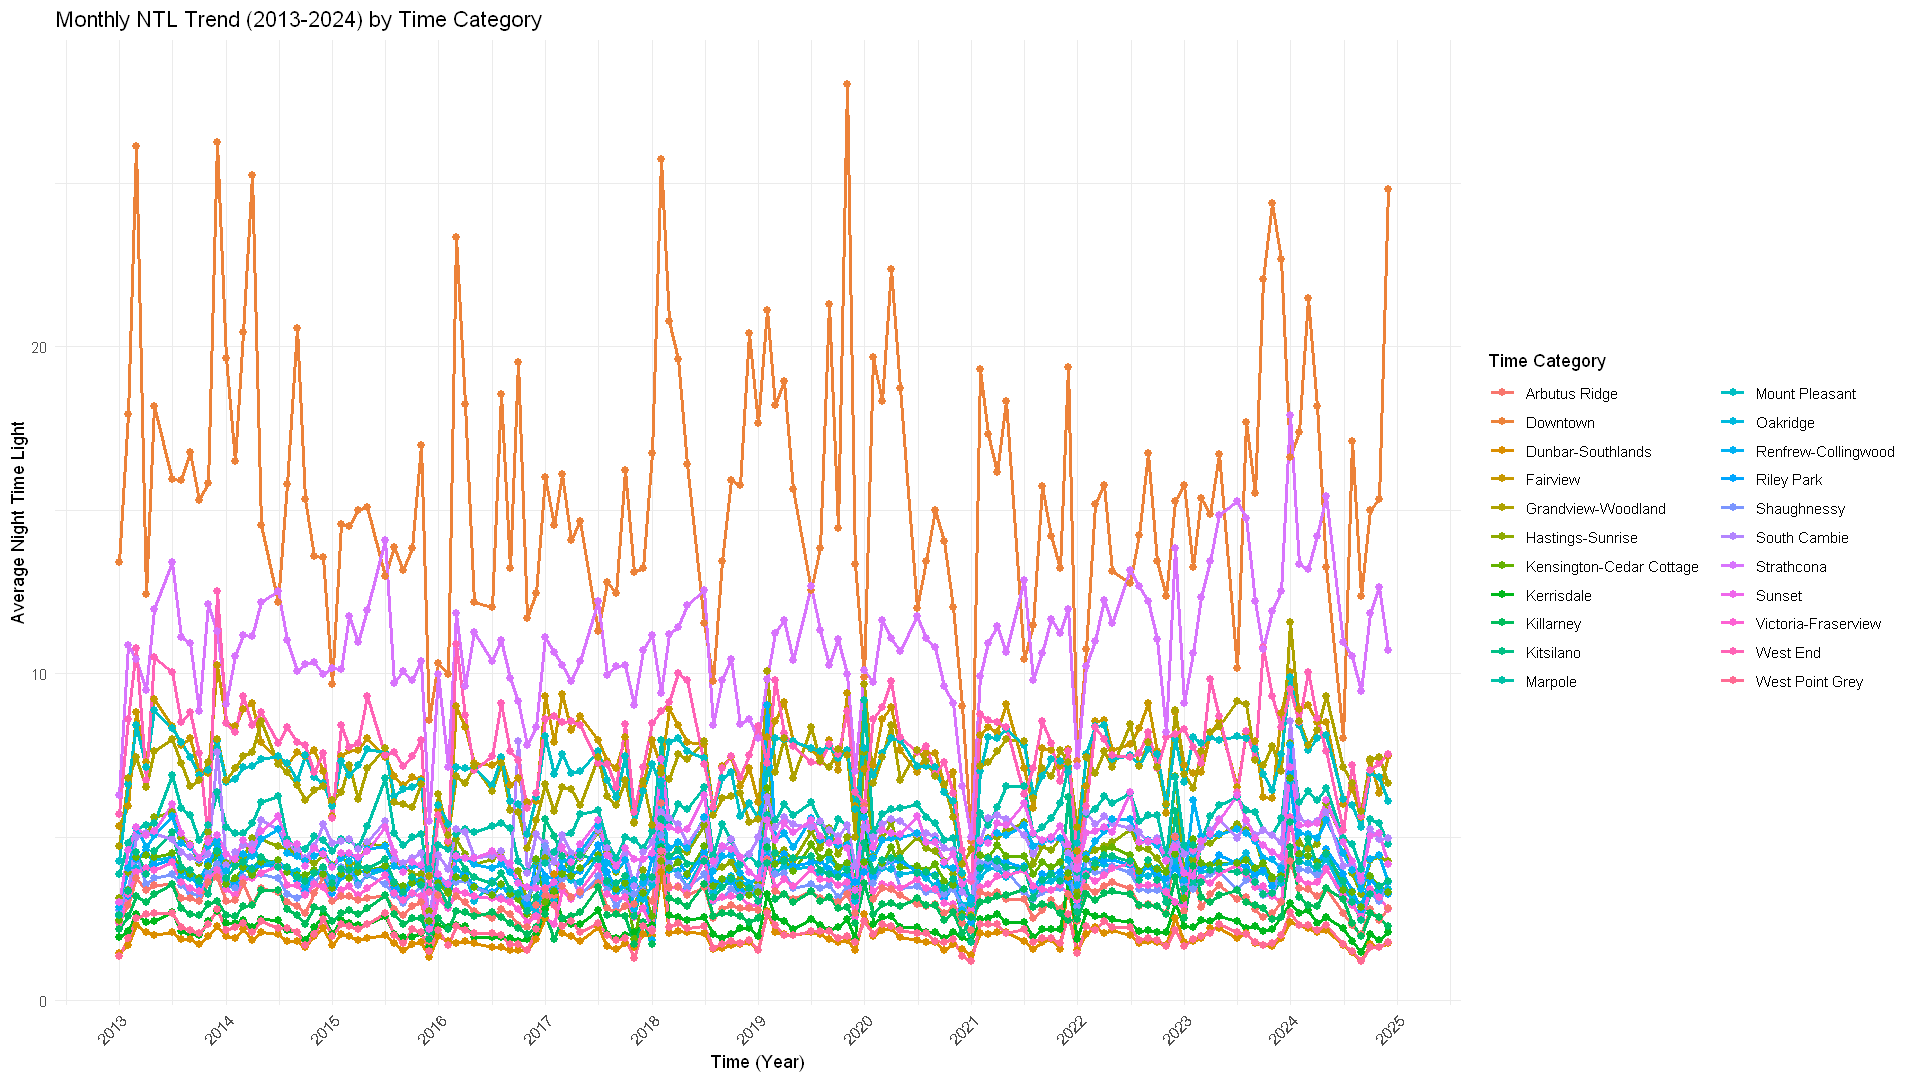

In [43]:
options(repr.plot.width = 16, repr.plot.height = 9)

ggplot(ntl_12_24_monthly, aes(x = date, y = ntl_mean, color = name, group = name)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [48]:
crime_trend_neighborhood <- crime_all|>
    group_by(time_category, year, month, geo_local_area)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    filter(time_category == "night")|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()


Rows: 6,125
Columns: 6
$ time_category  <chr> "night", "night", "night", "night", "night", "night", "…
$ year           <dbl> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2…
$ month          <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ geo_local_area <chr> "Arbutus Ridge", "Downtown", "Dunbar-Southlands", "Fair…
$ crime_count    <int> 52, 740, 67, 201, 229, 126, 143, 38, 77, 235, 87, 123, …
$ date           <date> 2003-01-01, 2003-01-01, 2003-01-01, 2003-01-01, 2003-0…


Warning message:
"Removed 68 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 68 rows containing missing values or values outside the scale range
(`geom_point()`)."


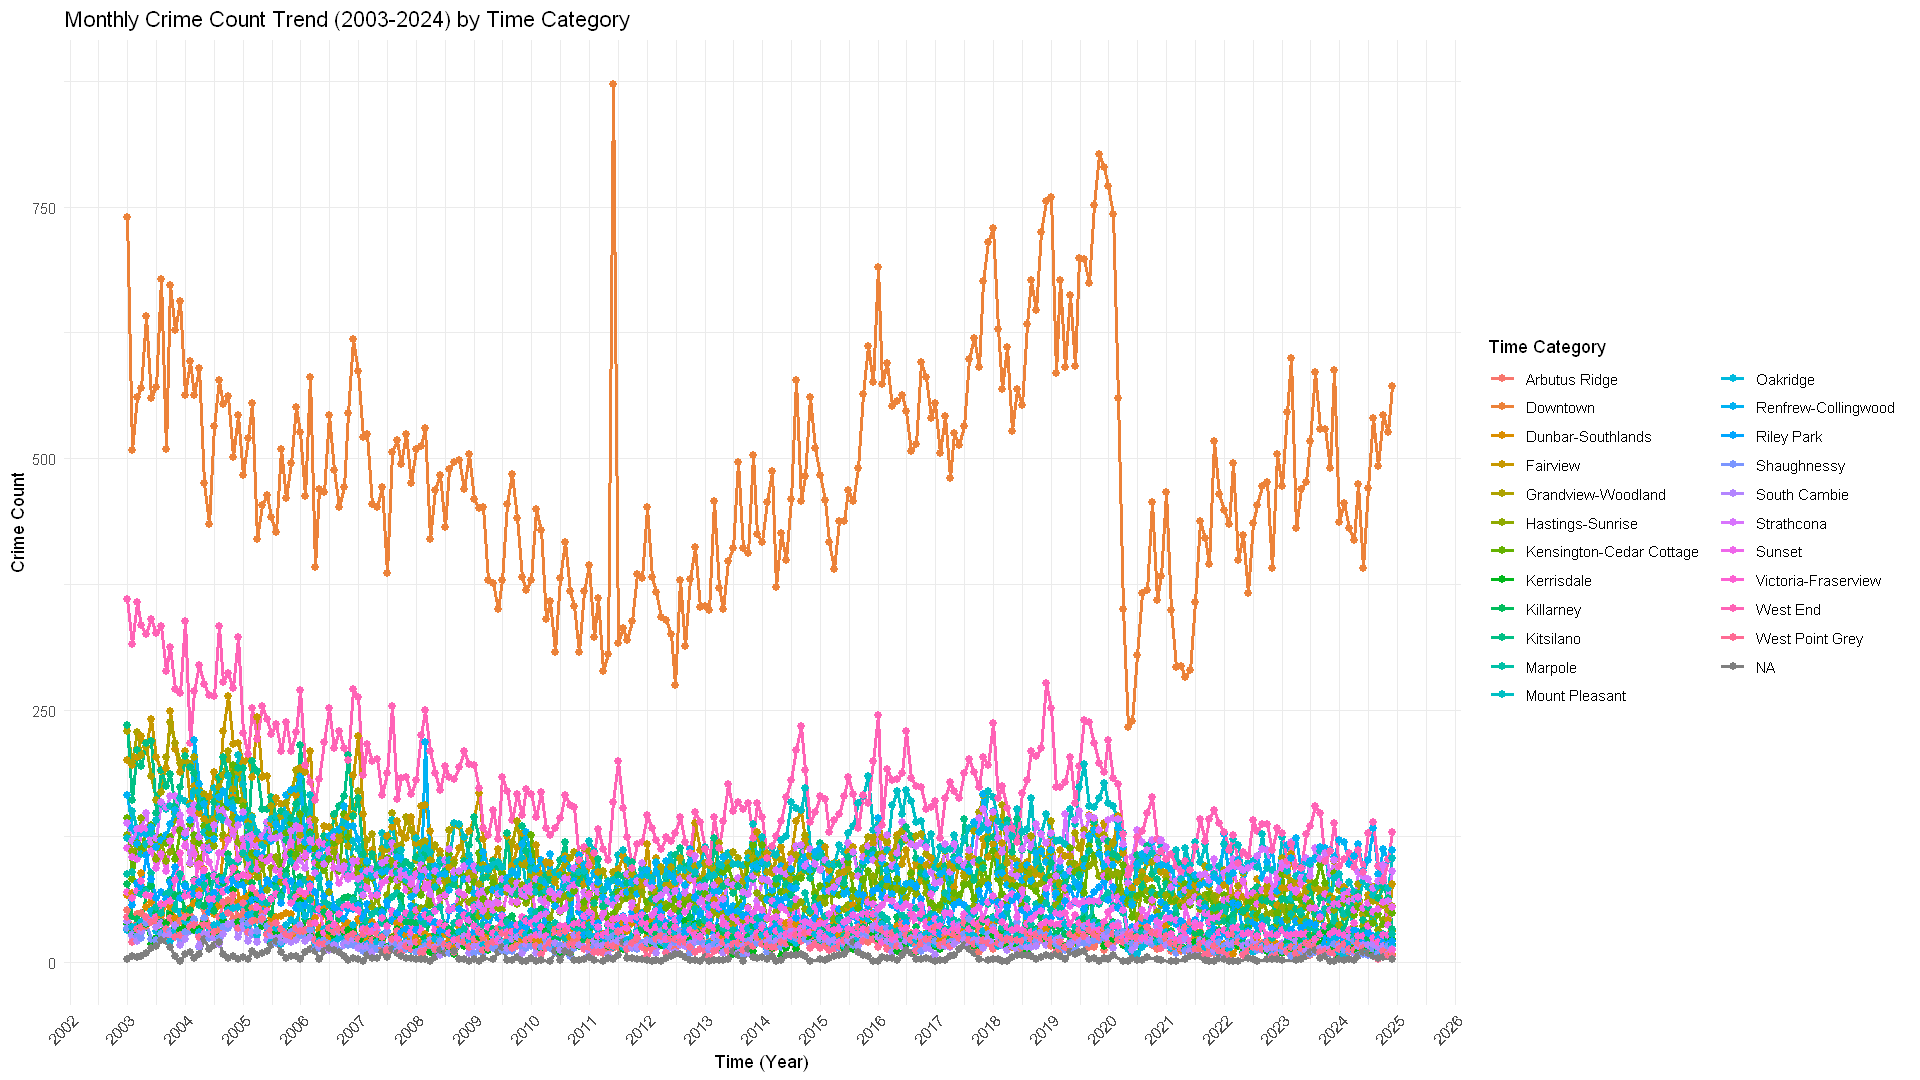

In [50]:

ggplot(crime_trend_neighborhood, aes(x = date, y = crime_count, color = geo_local_area, group = geo_local_area)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2003-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2003-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [55]:
crime_trend_dt_sc <- crime_all|>
    filter(geo_local_area %in% c("Downtown", "South Cambie"))|>
    group_by(time_category, year, month, geo_local_area)|>
    summarise(crime_count = n(), .groups = "drop")|>
    mutate(log_crime_count = log(crime_count))|>
    ungroup()|>
    filter(time_category == "night")|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 534
Columns: 7
$ time_category   <chr> "night", "night", "night", "night", "night", "night", …
$ year            <dbl> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, …
$ month           <dbl> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, …
$ geo_local_area  <chr> "Downtown", "South Cambie", "Downtown", "South Cambie"…
$ crime_count     <int> 740, 41, 508, 26, 561, 21, 570, 31, 641, 44, 560, 41, …
$ log_crime_count <dbl> 6.606650, 3.713572, 6.230481, 3.258097, 6.329721, 3.04…
$ date            <date> 2003-01-01, 2003-01-01, 2003-02-01, 2003-02-01, 2003-…


In [57]:
ntl_monthly_dt_sc <- ntl_12_24_monthly|>
    filter(name %in% c("Downtown", "South Cambie"))

Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`)."


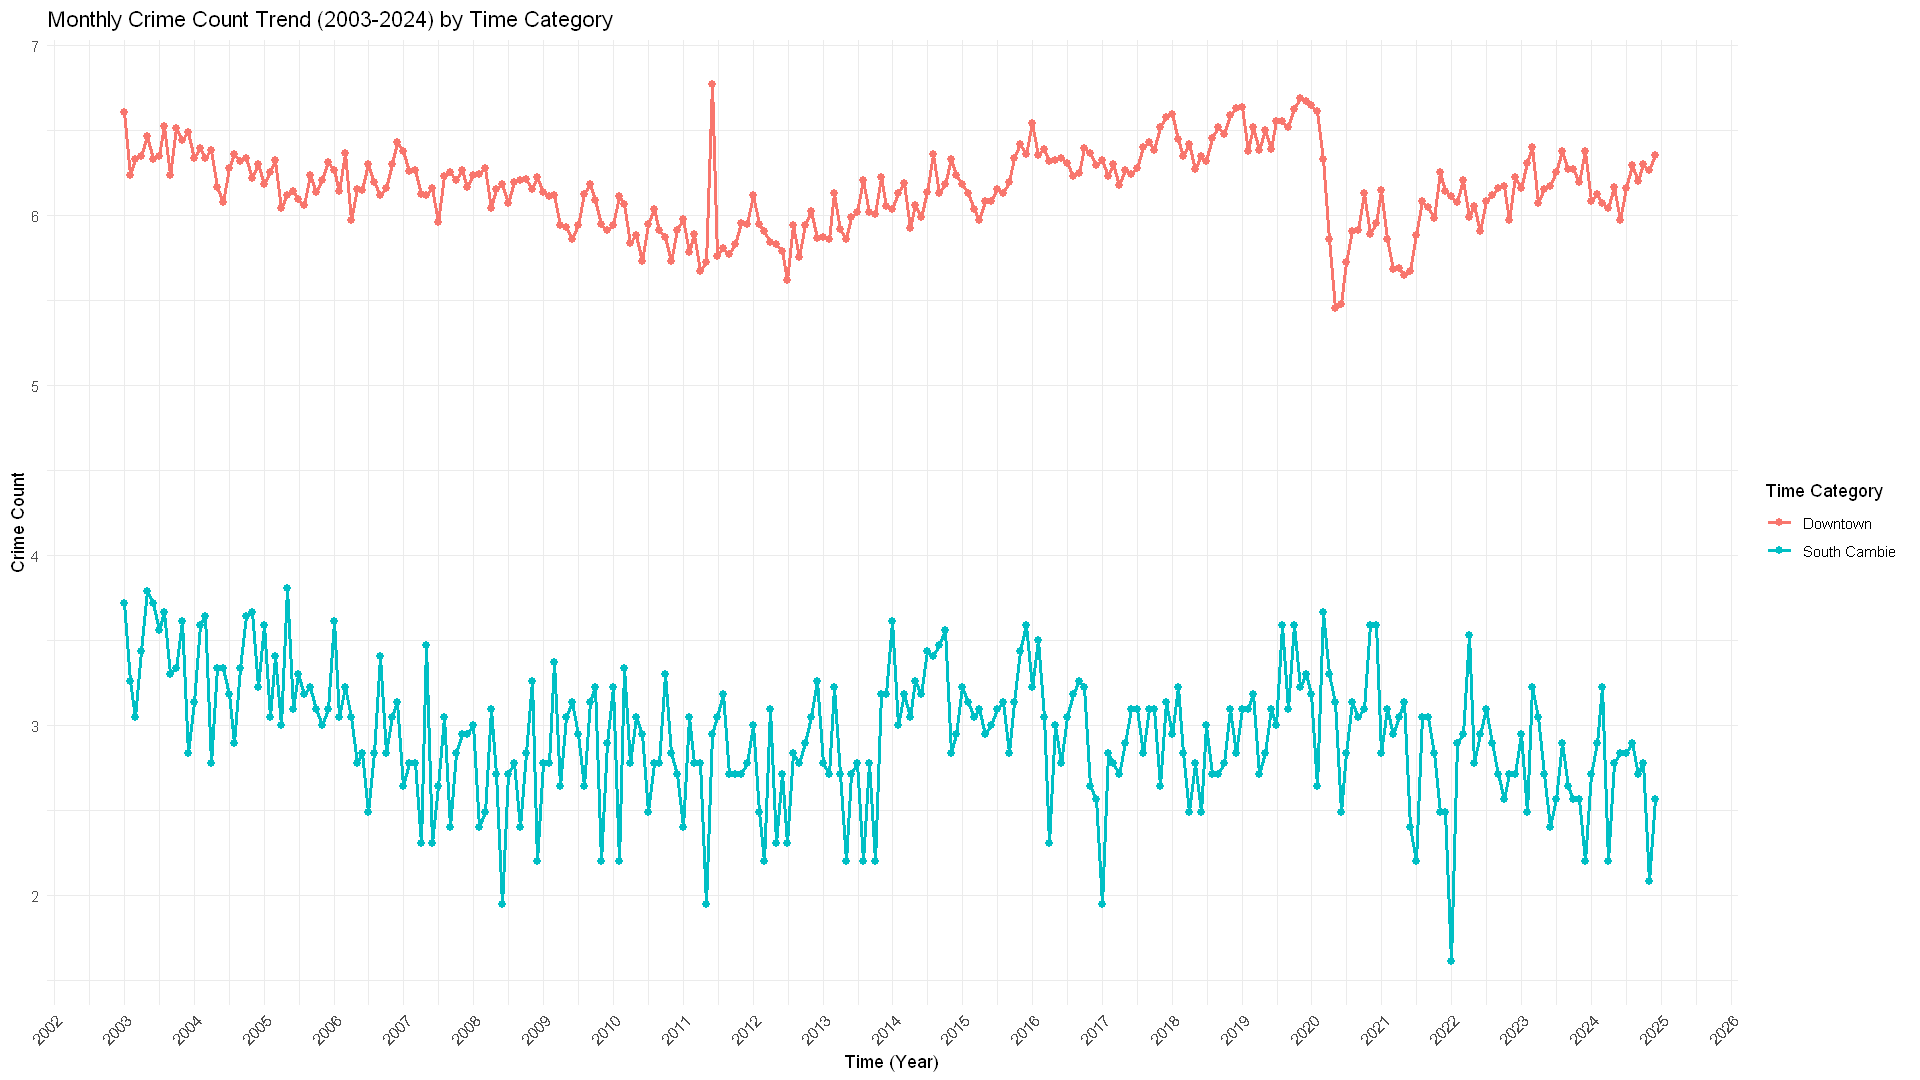

In [ ]:
ggplot(crime_trend_dt_sc, aes(x = date, y = log_crime_count, color = geo_local_area, group = geo_local_area)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2003-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Crime Count", 
       title = "Monthly Crime Count Trend (2003-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)) + 
  

Warning message:
"Removed 22 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 22 rows containing missing values or values outside the scale range
(`geom_point()`)."


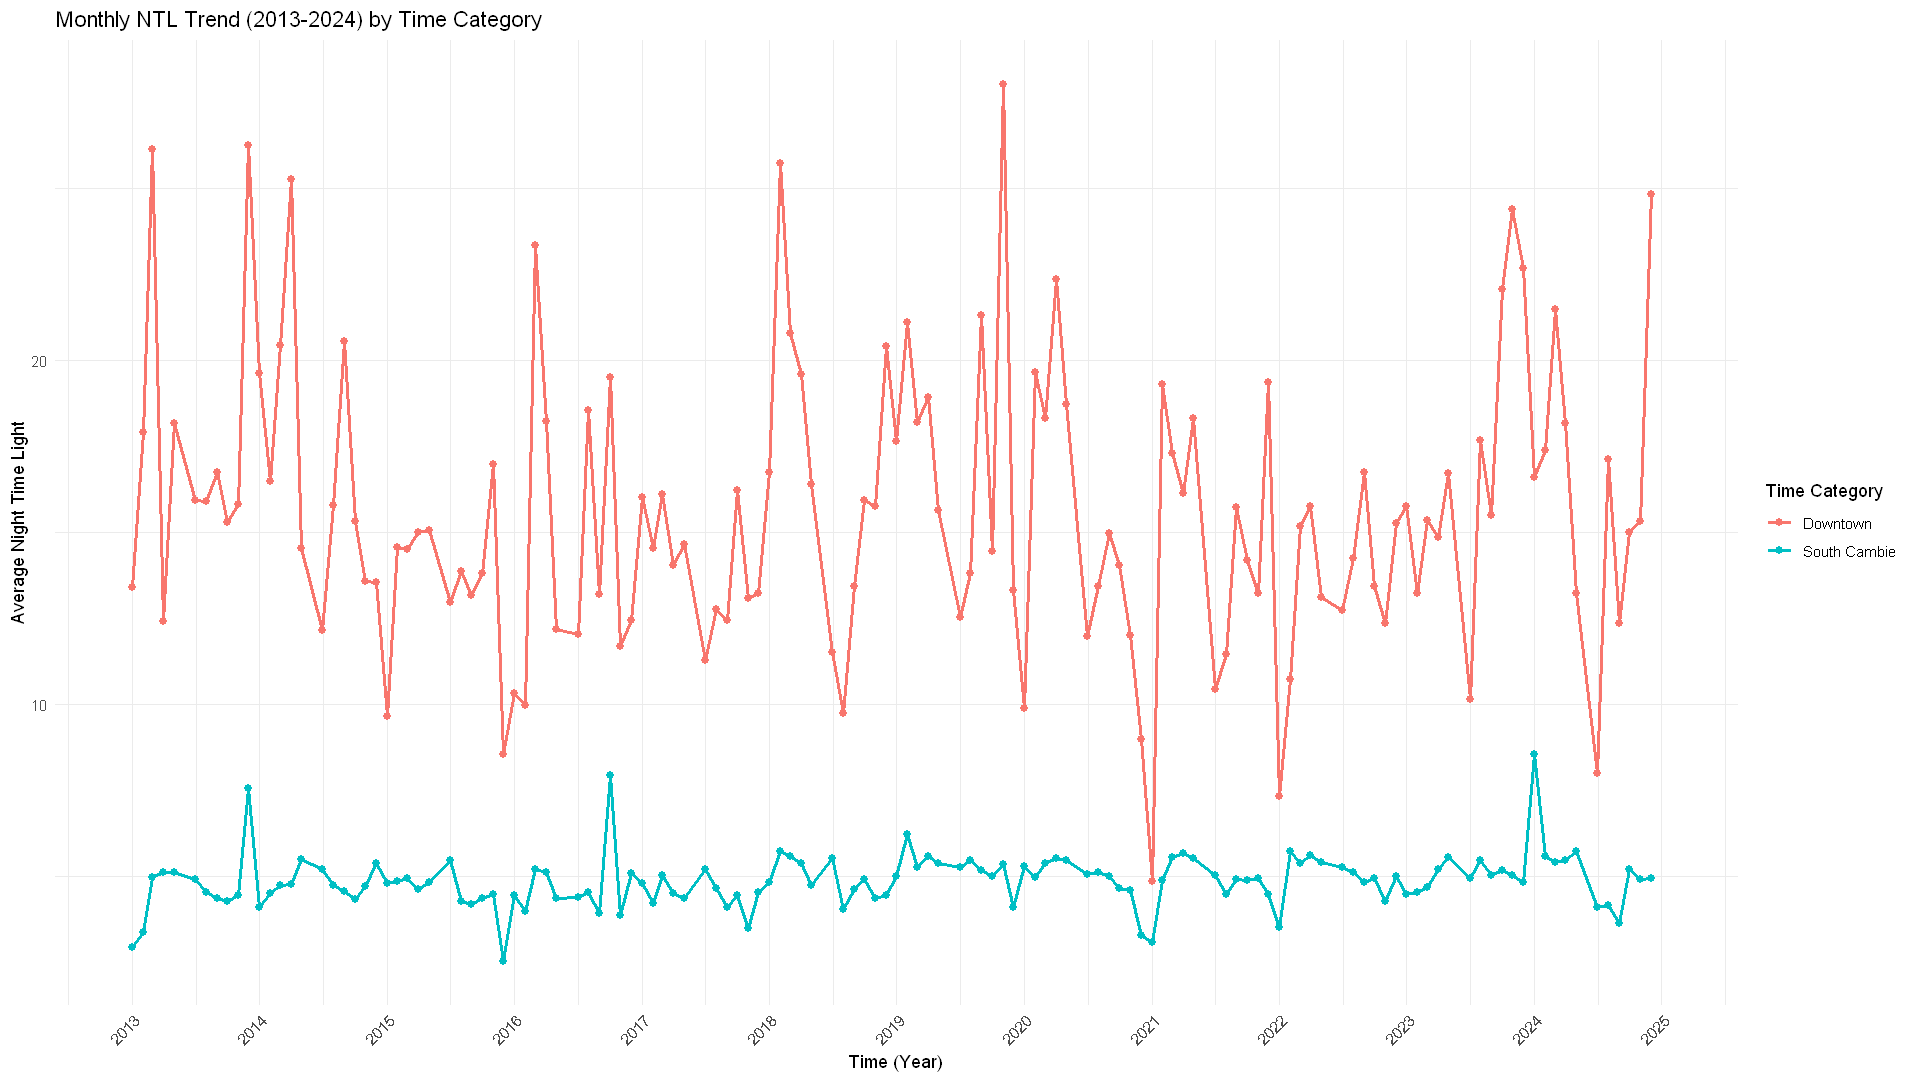

In [58]:
options(repr.plot.width = 16, repr.plot.height = 9)

ggplot(ntl_monthly_dt_sc, aes(x = date, y = ntl_mean, color = name, group = name)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
#   geom_smooth(method = "lm") +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2013-01-01", "2024-12-31"))) +
  labs(x = "Time (Year)", y = "Average Night Time Light", 
       title = "Monthly NTL Trend (2013-2024) by Time Category",
       color = "Time Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))